C:\Users\flori\AppData\Local\Temp\ipykernel_26808\1815846051.py:182: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c] for c in df.columns],
C:\Users\flori\AppData\Local\Temp\ipykernel_26808\1815846051.py:182: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c] for c in df.columns],
C:\Users\flori\AppData\Local\Temp\ipykernel_26808\1815846051.py:182: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c] for c in df.columns],


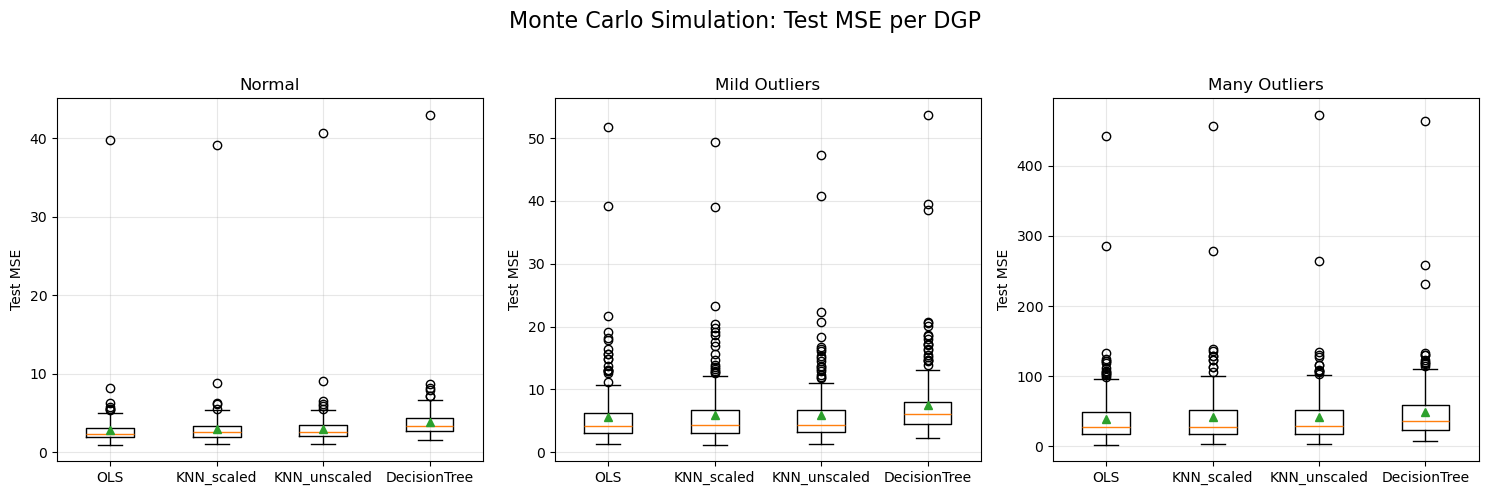


Normal, no outliers:
 OLS             2.848
KNN_scaled      2.976
KNN_unscaled    3.027
DecisionTree    3.831
dtype: float64

Mild outliers:
 OLS             5.642
KNN_scaled      5.885
KNN_unscaled    5.892
DecisionTree    7.515
dtype: float64

Many outliers:
 OLS             39.653
KNN_scaled      41.207
KNN_unscaled    41.371
DecisionTree    49.035
dtype: float64
=== Normal, no outliers ===
Paired t-tests (MSE) between models:

OLS vs KNN_scaled: t=-7.271, p=0.000
OLS vs KNN_unscaled: t=-7.866, p=0.000
OLS vs DecisionTree: t=-18.844, p=0.000
KNN_scaled vs KNN_unscaled: t=-1.941, p=0.054
KNN_scaled vs DecisionTree: t=-15.109, p=0.000
KNN_unscaled vs DecisionTree: t=-15.361, p=0.000

=== Mild outliers ===
Paired t-tests (MSE) between models:

OLS vs KNN_scaled: t=-5.453, p=0.000
OLS vs KNN_unscaled: t=-4.303, p=0.000
OLS vs DecisionTree: t=-11.181, p=0.000
KNN_scaled vs KNN_unscaled: t=-0.111, p=0.912
KNN_scaled vs DecisionTree: t=-10.735, p=0.000
KNN_unscaled vs DecisionTree: t=-9.0

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel  

def generate_data_no_outliers(n, seed=42):
    np.random.seed(seed)
    lsales = np.random.normal(8.3, 1.0, n)     
    roe = np.random.normal(17.2, 8.5, n)       
    finance = np.random.binomial(1, 0.3, n)
    consprod = np.random.binomial(1, 0.3, n)
    utility = np.random.binomial(1, 0.2, n)

    lsales_c = lsales - lsales.mean()
    lsales_c_sq = lsales_c ** 2

    eps = np.random.standard_t(df=3, size=n)

    y = (1.5 + 0.25*lsales_c - 0.05*lsales_c_sq +
         0.005*roe + 0.1*finance +
         0.35*consprod - 0.3*utility + eps)

    X = pd.DataFrame({
        'lsales_c': lsales_c,
        'lsales_c_sq': lsales_c_sq,
        'roe': roe,
        'finance': finance,
        'consprod': consprod,
        'utility': utility
    })
    return X, y

def generate_data_mild_outliers(n, seed=42):
    np.random.seed(seed)
    lsales = np.random.normal(8.3, 1.0, n)
    roe = np.random.normal(17.2, 8.5, n)
    finance = np.random.binomial(1, 0.3, n)
    consprod = np.random.binomial(1, 0.3, n)
    utility = np.random.binomial(1, 0.2, n)

    lsales_c = lsales - lsales.mean()
    lsales_c_sq = lsales_c ** 2

    eps = np.random.standard_t(df=3, size=n)
    out_idx = np.random.choice(n, size=int(0.05*n), replace=False)
    eps[out_idx] *= 5

    y = (1.5 + 0.25*lsales_c - 0.05*lsales_c_sq +
         0.005*roe + 0.1*finance +
         0.35*consprod - 0.3*utility + eps)

    X = pd.DataFrame({
        'lsales_c': lsales_c,
        'lsales_c_sq': lsales_c_sq,
        'roe': roe,
        'finance': finance,
        'consprod': consprod,
        'utility': utility
    })
    return X, y

def generate_data_many_outliers(n, seed=42):
    np.random.seed(seed)
    lsales = np.random.normal(8.3, 1.0, n)
    roe = np.random.normal(17.2, 8.5, n)
    finance = np.random.binomial(1, 0.3, n)
    consprod = np.random.binomial(1, 0.3, n)
    utility = np.random.binomial(1, 0.2, n)

    lsales_c = lsales - lsales.mean()
    lsales_c_sq = lsales_c ** 2

    eps = np.random.standard_t(df=3, size=n)
    out_idx = np.random.choice(n, size=int(0.15*n), replace=False)
    eps[out_idx] *= 10

    y = (1.5 + 0.25*lsales_c - 0.05*lsales_c_sq +
         0.005*roe + 0.1*finance +
         0.35*consprod - 0.3*utility + eps)

    X = pd.DataFrame({
        'lsales_c': lsales_c,
        'lsales_c_sq': lsales_c_sq,
        'roe': roe,
        'finance': finance,
        'consprod': consprod,
        'utility': utility
    })
    return X, y

def select_k_nested_knn(train_df, k_grid=range(3,16),
                        k_outer=5, k_inner=5,
                        seed_outer=42, seed_inner=1):
    X = train_df.drop(columns=['y']).values
    y = train_df['y'].values

    outer_cv = KFold(n_splits=k_outer, shuffle=True, random_state=seed_outer)
    inner_cv = KFold(n_splits=k_inner, shuffle=True, random_state=seed_inner)

    best_ks = []
    for outer_train_idx, _ in outer_cv.split(X):
        X_outer = X[outer_train_idx]
        y_outer = y[outer_train_idx]

        mse_per_k = []
        for k in k_grid:
            inner_mse = []
            for itrain, ival in inner_cv.split(X_outer):
                X_it, X_iv = X_outer[itrain], X_outer[ival]
                y_it, y_iv = y_outer[itrain], y_outer[ival]

                pipe = Pipeline([
                    ('scaler', StandardScaler()),
                    ('knn', KNeighborsRegressor(n_neighbors=k))
                ])
                pipe.fit(X_it, y_it)
                y_pred = pipe.predict(X_iv)
                inner_mse.append(mean_squared_error(y_iv, y_pred))
            mse_per_k.append(np.mean(inner_mse))
        best_ks.append(k_grid[np.argmin(mse_per_k)])

    return int(np.median(best_ks))


def monte_carlo_sim(DGP_fun, n_sim=200, n=209):
    results = {
        'OLS': [],
        'KNN_scaled': [],
        'KNN_unscaled': [],
        'DecisionTree': []
    }

    for sim in range(n_sim):
        X, y = DGP_fun(n=n, seed=sim)
        df = X.copy()
        df['y'] = y

        train_df, test_df = train_test_split(df, test_size=0.2, random_state=sim)
        X_train = train_df.drop(columns=['y'])
        y_train = train_df['y']
        X_test = test_df.drop(columns=['y'])
        y_test = test_df['y']

        # OLS 
        ols = LinearRegression()
        ols.fit(X_train, y_train)
        results['OLS'].append(mean_squared_error(y_test, ols.predict(X_test)))

        # KNN scaled 
        best_k = select_k_nested_knn(train_df)
        knn_scaled = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsRegressor(n_neighbors=best_k))
        ])
        knn_scaled.fit(X_train, y_train)
        results['KNN_scaled'].append(mean_squared_error(y_test, knn_scaled.predict(X_test)))

        # KNN unscaled 
        knn_unscaled = KNeighborsRegressor(n_neighbors=best_k)
        knn_unscaled.fit(X_train, y_train)
        results['KNN_unscaled'].append(mean_squared_error(y_test, knn_unscaled.predict(X_test)))

        # Decision Tree 
        dt = DecisionTreeRegressor(min_samples_leaf=5, random_state=sim)
        dt.fit(X_train, y_train)
        results['DecisionTree'].append(mean_squared_error(y_test, dt.predict(X_test)))

    return pd.DataFrame(results)

def plot_results_boxplot(results_dict, title):
    n = len(results_dict)
    plt.figure(figsize=(5*n,5))
    for i, (dgp_name, df) in enumerate(results_dict.items(), start=1):
        plt.subplot(1, n, i)
        plt.boxplot([df[c] for c in df.columns],
                    labels=df.columns,
                    showmeans=True)
        plt.title(dgp_name)
        plt.ylabel("Test MSE")
        plt.grid(alpha=0.3)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

def test_significance(results_df):
    """
    Perform paired t-tests between all model pairs.
    results_df: DataFrame with columns for each model
    """
    models = results_df.columns
    n_models = len(models)
    
    print("Paired t-tests (MSE) between models:\n")
    for i in range(n_models):
        for j in range(i+1, n_models):
            m1 = models[i]
            m2 = models[j]
            t_stat, p_val = ttest_rel(results_df[m1], results_df[m2])
            print(f"{m1} vs {m2}: t={t_stat:.3f}, p={p_val:.3f}")

results_normal = monte_carlo_sim(generate_data_no_outliers)
results_mild = monte_carlo_sim(generate_data_mild_outliers)
results_many = monte_carlo_sim(generate_data_many_outliers)  

results_dict = {
    "Normal": results_normal,
    "Mild Outliers": results_mild,
    "Many Outliers": results_many,
}
plot_results_boxplot(results_dict, "Monte Carlo Simulation: Test MSE per DGP")

print("\nNormal, no outliers:\n", results_normal.mean().round(3))
print("\nMild outliers:\n", results_mild.mean().round(3))
print("\nMany outliers:\n", results_many.mean().round(3))

print("=== Normal, no outliers ===")
test_significance(results_normal)

print("\n=== Mild outliers ===")
test_significance(results_mild)

print("\n=== Many outliers ===")
test_significance(results_many)
